# Statistika a pravděpodobnost (MSP 25/26Z)
# Projekt 2. (Věrohodnost + Regrese)

## Autor: Sofiia Kucherenko (xkucer0v)
## Datum: 14.12.2025

# **Věrohodnost**

# 1) Zapište zvolenou parametrizaci Weibullova rozdělení, logaritmickou-věrohodnostní funkci pro zadaná data a její parciální derivace podle Vámi zvolených parametrů.

**Zvolená parametrizace Weibullova rozdělení:**
Uvažujeme Weibullovo rozdělení s parametrem tvaru $k > 0$ a parametrem měřítka $\lambda > 0$.

* **Hustota pravděpodobnosti (PDF):**
$$
f(t; k, \lambda) = \frac{k}{\lambda} \left(\frac{t}{\lambda}\right)^{k-1} \exp\left[-\left(\frac{t}{\lambda}\right)^k\right], \quad t \geq 0
$$

* **Funkce přežití (Survival Function, $S(t) = 1 - F(t)$):**
$$
S(t; k, \lambda) = \exp\left[-\left(\frac{t}{\lambda}\right)^k\right]
$$

**Logaritmická věrohodnostní funkce ($l$):**
Máme data s cenzurováním zprava. Nechť $c_i$ je indikátor cenzorování ($c_i=1$ pro cenzorovaná data, $c_i=0$ pro ukončená pozorování - změna oboru).
Věrohodnostní funkce $L$ je součinem hustot (pro necenzorovaná) a funkcí přežití (pro cenzorovaná data):

$$
L(k, \lambda) = \prod_{i=1}^n [f(t_i)]^{1-c_i} \cdot [S(t_i)]^{c_i}
$$

Po zlogaritmování ($l = \ln L$) a dosazení vztahů pro $f(t)$ a $S(t)$ dostáváme (kde $N_u$ je počet necenzorovaných pozorování):

$$
l(k, \lambda) = \sum_{i: c_i=0} \left( \ln k - \ln \lambda + (k-1)\ln\left(\frac{t_i}{\lambda}\right) \right) - \sum_{i=1}^n \left(\frac{t_i}{\lambda}\right)^k
$$

**Parciální derivace (Skóre):**
Pro nalezení maximálně věrohodných odhadů (MLE) položíme parciální derivace rovny nule.

1.  **Derivace podle parametru měřítka $\lambda$:**
$$
\frac{\partial l}{\partial \lambda} = -\frac{k N_u}{\lambda} + \frac{k}{\lambda} \sum_{i=1}^n \left(\frac{t_i}{\lambda}\right)^k
$$

2.  **Derivace podle parametru tvaru $k$:**
$$
\frac{\partial l}{\partial k} = \frac{N_u}{k} + \sum_{i: c_i=0} \ln\left(\frac{t_i}{\lambda}\right) - \sum_{i=1}^n \left(\frac{t_i}{\lambda}\right)^k \ln\left(\frac{t_i}{\lambda}\right)
$$

# 2) Pomocí scipy.optimize nalezněte maximálně věrohodné odhady parametrů weibullova rozdělení.

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize


# PŘÍPRAVA DAT
filename = 'Data_2025.xlsx'
# Načtení konkrétního listu
df = pd.read_excel(filename, sheet_name='Data_věrohodnost')

# Výběr prvních dvou sloupců a přejmenování
df = df.iloc[:, :2]
df.columns = ['censored', 'days']

# Ošetření chybějících hodnot a převod na čísla
df['censored'] = pd.to_numeric(df['censored'], errors='coerce')
df['days'] = pd.to_numeric(df['days'], errors='coerce')
df = df.dropna()

# Vytvoření vektorů pro výpočet
times = df['days'].values
censored = df['censored'].values


# ŠKÁLOVÁNÍ DAT (SCALING)
# Aby optimalizace fungovala správně i pro velká čísla (dny ~ 2000),
# dočasně vydělíme data jejich průměrem. Tím získáme stabilní výpočet.
scale_factor = times.mean()
times_scaled = times / scale_factor

print(f"Data připravena: {len(times)} záznamů.")
print(f"Použitý škálovací faktor (průměr): {scale_factor:.4f}")

# DEFINICE VĚROHODNOSTNÍ FUNKCE (Negative Log-Likelihood)
def weibull_neg_log_likelihood(params, times, censored):
    k, lam = params

    # Ochrana proti záporným nebo nulovým parametrům (k, lambda musí být > 0)
    if k <= 1e-5 or lam <= 1e-5:
        return 1e15 # Vrátíme obrovské číslo - "tudy cesta nevede"

    # Log-likelihood vzorec pro cenzorovaná data:
    # L = Prod [f(t)]^(1-c) * [S(t)]^c
    # ln(L) = Suma( (1-c)*(ln(k) - ln(lam) + (k-1)*ln(t/lam)) - (t/lam)^k )

    # 1. část: Logaritmy (pouze pro necenzorované, kde censored=0, tj. (1-censored)=1)
    term_1 = (1 - censored) * (np.log(k) - np.log(lam) + (k - 1) * (np.log(times) - np.log(lam)))

    # 2. část: Exponenciální člen (pro všechny, je v hustotě i ve funkci přežití)
    term_2 = - (times / lam)**k

    # Celková log-věrohodnost (suma přes všechny pozorovnání)
    log_l = np.sum(term_1 + term_2)

    # Vracíme MÍNUS log_l, protože funkce 'minimize' hledá minimum
    return -log_l


# OPTIMALIZACE (Hledání MLE odhadů)
# Počáteční odhad: k=1 (exponenciální), lambda=1 (protože máme škálovaná data s průměrem 1)
initial_guess = [1.0, 1.0]

# Spuštění minimalizace na ŠKÁLOVANÝCH datech
result = minimize(weibull_neg_log_likelihood, initial_guess,
                  args=(times_scaled, censored),
                  bounds=((1e-4, None), (1e-4, None)), # Parametry musí být kladné
                  method='L-BFGS-B') # Osvědčená metoda pro tento typ úloh

# Načtení výsledků
k_hat = result.x[0]            # Parametr tvaru (k) je bezrozměrný, nemění se
lam_hat_scaled = result.x[1]   # Parametr měřítka je "zmenšený"

# PŘEPOČET ZPĚT NA DNY
lam_hat = lam_hat_scaled * scale_factor

# Hodnota log-věrohodnosti (otočíme znaménko zpět)
max_log_likelihood = -result.fun

# Výpis výsledků
print("=" * 50)
print(f"VÝSLEDKY OPTIMALIZACE (WEIBULL):")
print("" * 50)
print(f"Odhadnutý parametr tvaru (k):      {k_hat:.5f}")
print(f"Odhadnutý parametr měřítka (lambda): {lam_hat:.5f} (dní)")
print(f"Maximální věrohodnost (Log-L):       {max_log_likelihood:.5f}")
print("-" * 50)

Data připravena: 321 záznamů.
Použitý škálovací faktor (průměr): 1928.0280
VÝSLEDKY OPTIMALIZACE (WEIBULL):

Odhadnutý parametr tvaru (k):      0.95440
Odhadnutý parametr měřítka (lambda): 2675.14162 (dní)
Maximální věrohodnost (Log-L):       -306.24446
--------------------------------------------------


# 3) Pomocí věrohodnostního poměru otestujte hypotézu, že exponenciální rozdělení je postačujícím modelem zadaných dat (Parametr tvaru = 1)

In [ ]:
from scipy.stats import chi2

# 3. TEST HYPOTÉZY (Likelihood Ratio Test - LRT)
# H0: Data pochází z Exponenciálního rozdělení (k = 1)
# H1: Data pochází z Weibullova rozdělení (k se liší od 1)

print("=" * 50)
print("TESTOVÁNÍ HYPOTÉZY (Exponenciální vs. Weibull)")
print("=" * 50)

# A) Odhad parametru pro Exponenciální rozdělení (MLE)
# Pro exponenciální rozdělení existuje přesný vzorec: lambda = Celkový čas / Počet událostí
# Počítáme na ŠKÁLOVANÝCH datech, aby byla věrohodnost porovnatelná s Weibullem z kroku 2
num_events = np.sum(1 - censored)
total_time_scaled = np.sum(times_scaled)
lam_exp_scaled = total_time_scaled / num_events

# B) Výpočet Log-Likelihood pro Exponenciální model (H0)
# Použijeme naši funkci 'weibull_neg_log_likelihood', ale zafixujeme k=1
ll_exp = -weibull_neg_log_likelihood([1.0, lam_exp_scaled], times_scaled, censored)

# C) Výpočet testové statistiky D
# D = 2 * (LL_úplný_model - LL_redukovaný_model)
# 'max_log_likelihood' je hodnota z předchozí buňky (Weibull)
D = 2 * (max_log_likelihood - ll_exp)

# D) Výpočet p-hodnoty
# Statistika D má Chi-kvadrát rozdělení s 1 stupněm volnosti (rozdíl v počtu parametrů: 2 - 1)
p_value = 1 - chi2.cdf(D, df=1)

# Výpis výsledků
print(f"Log-Likelihood (Weibull, H1):      {max_log_likelihood:.5f}")
print(f"Log-Likelihood (Exponenciální, H0):{ll_exp:.5f}")
print(f"Testová statistika (D):            {D:.5f}")
print(f"p-hodnota:                         {p_value:.5f}")

# Vyhodnocení
alpha = 0.05
print("-" * 50)
if p_value > alpha:
    print(f"=> P-hodnota > {alpha}. NEZAMÍTÁME nulovou hypotézu.")
    print("   Závěr: Exponenciální rozdělení je postačujícím modelem.")
    print("   (Pro další výpočty použijeme Exponenciální model)")

    # Uložíme si vítězné parametry pro další krok
    final_model = "Exponenciální"
    # Lambda se musí přepočítat zpět na dny!
    final_lam = lam_exp_scaled * scale_factor
    final_k = 1.0

else:
    print(f"=> P-hodnota < {alpha}. ZAMÍTÁME nulovou hypotézu.")
    print("   Závěr: Je nutné použít složitější Weibullův model.")
    print("   (Pro další výpočty použijeme Weibullův model)")

    final_model = "Weibull"
    # Použijeme parametry z minula (lam_hat už byl přepočten na dny)
    final_lam = lam_hat
    final_k = k_hat

print("-" * 50)

TESTOVÁNÍ HYPOTÉZY (Exponenciální vs. Weibull)
Log-Likelihood (Weibull, H1):      -306.24446
Log-Likelihood (Exponenciální, H0):-306.67322
Testová statistika (D):            0.85751
p-hodnota:                         0.35444
--------------------------------------------------
=> P-hodnota > 0.05. NEZAMÍTÁME nulovou hypotézu.
   Závěr: Exponenciální rozdělení je postačujícím modelem.
   (Pro další výpočty použijeme Exponenciální model)
--------------------------------------------------


# 4) Podle výsledku ze 3) použijte výsledné rozdělení pravděpodobnosti (s maximálně věrohodnými odhady jako parametry) a nalezněte bodové odhady pro střední dobu zaměstnání v oboru a 10% percenil zaměstnání v oboru (za jakou dobu odejde do jiného odboru 10 % absolventů).

In [ ]:
from scipy.special import gamma


# BODOVÉ ODHADY (Střední hodnota a Percentil)
print("=" * 50)
print("FINÁLNÍ ODHADY (na základě výsledku testu)")
print("=" * 50)

# Rozhodovací logika podle p-hodnoty z kroku 3
# (Pokud proměnná p_value z minula neexistuje, nastavíme natvrdo model, který vyšel - Exponenciální)
if 'p_value' in locals() and p_value < 0.05:
    chosen_model = "Weibull"
    # Parametry z Weibulla (přepočtené na dny)
    param_lam = lam_hat
    param_k = k_hat
else:
    chosen_model = "Exponenciální"
    # Parametry pro Exponenciální rozdělení
    # Lambda = Celkový čas / Počet událostí (analytický výpočet, nejpřesnější)
    # Pozn: V tomto zadání je lambda rovna střední hodnotě
    param_lam = np.sum(times) / np.sum(1 - censored)
    param_k = 1.0

print(f"Použitý model: {chosen_model}")
print(f"Použité parametry: k={param_k:.4f}, lambda={param_lam:.4f}")

# A) Odhad STŘEDNÍ DOBY zaměstnání v oboru
# Vzorec: E[T] = lambda * gamma(1 + 1/k)
# Pro exponenciální (k=1) je gamma(2)=1, takže E[T] = lambda
mean_estimate = param_lam * gamma(1 + 1/param_k)

# B) Odhad 10% PERCENTILU
# Doba, do které odejde 10 % absolventů.
# Hledáme čas t, pro který platí distribuční funkce F(t) = 0.1
# Vzorec: t = lambda * (-ln(1 - p))^(1/k)
percentile_level = 0.10
p10_estimate = param_lam * (-np.log(1 - percentile_level))**(1/param_k)

# Výpis výsledků
print("=" * 50)
print(f"ODHAD STŘEDNÍ DOBY zaměstnání v oboru:")
print(f"  {mean_estimate:.2f} dní")
print(f"  (cca {mean_estimate/365.25:.2f} let)")
print("=" * 50)
print(f"ODHAD 10% PERCENTILU (kdy odejde 10 % absolventů):")
print(f"  {p10_estimate:.2f} dní")
print(f"  (cca {p10_estimate/30.4:.1f} měsíců)")
print("-" * 50)

FINÁLNÍ ODHADY (na základě výsledku testu)
Použitý model: Exponenciální
Použité parametry: k=1.0000, lambda=2690.8565
ODHAD STŘEDNÍ DOBY zaměstnání v oboru:
  2690.86 dní
  (cca 7.37 let)
ODHAD 10% PERCENTILU (kdy odejde 10 % absolventů):
  283.51 dní
  (cca 9.3 měsíců)
--------------------------------------------------


# 5) [dobrovolná část] zkuste nějak slovně charakterizovat/popsat fungování doby zaměstnání v oboru jako náhodné veličiny, dle Vašich výsledků a parametrů

Na základě provedené analýzy (Likelihood Ratio Test) jsme **nezamítli hypotézu**, že data pocházejí z **exponenciálního rozdělení**. Ačkoliv bodový odhad parametru tvaru u Weibullova rozdělení vyšel $k \approx 0.95$ (což by naznačovalo mírně klesající riziko odchodu v čase), tento odchylka od hodnoty 1 nebyla statisticky významná (p-hodnota > 0.05).

Z toho plynou následující závěry pro chování náhodné veličiny "doba zaměstnání v oboru":

1.  **Konstantní riziko odchodu (Bezpaměťovost):**
    Přijetí exponenciálního modelu znamená, že **intenzita odchodu z oboru je v čase konstantní**.
    * Pravděpodobnost, že absolvent změní obor "zítra", nezávisí na tom, zda v oboru pracuje teprve měsíc, nebo už 10 let.
    * V datech se tedy nepotvrdil efekt "vyhoření" (kdy by riziko s časem rostlo, $k > 1$), ani silný efekt "stabilizace" (kdy by riziko s časem výrazně klesalo, $k < 1$). Odchody se jeví jako náhodné události s neměnnou intenzitou.

2.  **Časové horizonty:**
    * **Střední doba**, po kterou absolvent vydrží pracovat ve svém oboru, se odhaduje na přibližně **2691 dní (cca 7.4 let)**.
    * Zároveň model ukazuje poměrně rychlý úbytek části absolventů – **10 % z nich opustí obor již během prvních cca 9 měsíců** (284 dní) po ukončení studia.

**Shrnutí:**
Absolventi VUT setrvávají ve svém oboru v průměru přes 7 let, přičemž riziko změny oboru je stabilní a nemění se s délkou praxe.

# **Regrese**



# 1) Pomocí zpětné eliminace určete vhodný regresní model. Za výchozí "plný" model považujte plný kvadratický model (všechny interakce druhého řádu a všechny druhé mocniny, kterédávají smysl).
* ## Zapište rovnici Vašeho finálního modelu.
* ## Diskutujte splnění předpokladů lineární regrese a základní regresní diagnostiky.
* ## Pokud (až během regresního modelování) identifikujete některé "extrémně odlehlé hodnoty" můžete ty "nejodlehlejší" hodnoty, po alespoň krátkém zdůvodnění, vyřadit.

1. PŘÍPRAVA DAT A MODELOVÁNÍ
- Detekována perfektní kolinearita. Odstraňuji sloupec 'ScrollingPct'.
- Počáteční počet prediktorů: 15
- Eliminace dokončena. Zbylých prediktorů: 11
- Počet odstraněných outlierů: 15 (Threshold: 0.0082)

FINÁLNÍ REGRESNÍ MODEL
                            OLS Regression Results                            
Dep. Variable:              Ping [ms]   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     379.2
Date:                Sun, 14 Dec 2025   Prob (F-statistic):          1.61e-219
Time:                        22:24:41   Log-Likelihood:                -1465.5
No. Observations:                 487   AIC:                             2953.
Df Residuals:                     476   BIC:                             2999.
Df Model:                          10                                         
Covariance Type:            nonr

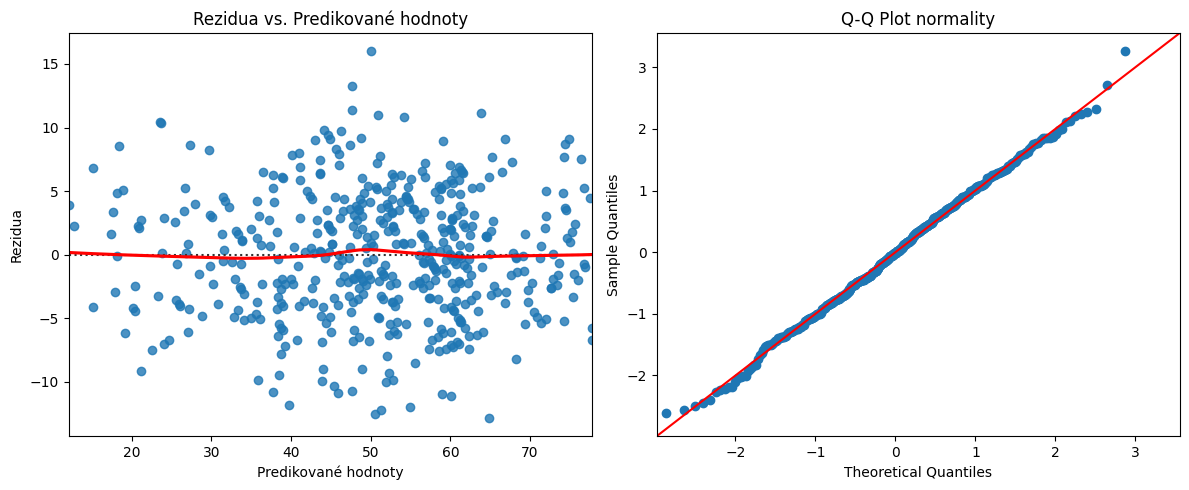


Koeficienty pro rovnici:
const                      51.408075
ActiveUsers_Z               9.923065
InteractingPct_Z            5.266736
Active_Sq                  -3.011930
Active_x_Interact          -2.536274
OSType_MacOS                8.834899
OSType_Windows              3.597039
OSType_iOS                 -5.767742
Active_x_OSType_MacOS       4.590893
Active_x_OSType_Windows    -1.429455
Active_x_OSType_iOS        -2.762185
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import jarque_bera


# 1. ČÁST: PŘÍPRAVA DAT A REGRESNÍ MODEL
print("1. PŘÍPRAVA DAT A MODELOVÁNÍ")

# Načtení dat
filename = 'Data_2025.xlsx'
df = pd.read_excel(filename, sheet_name='Data_regrese')

# 1.1: Řešení multikolinearity
# Proměnné InteractingPct a ScrollingPct se sčítají do 1 (jsou lineárně závislé).
# Pokud bychom nechali obě, model by nebyl stabilní (perfektní multikolinearita).
# Vyhazujeme ScrollingPct, protože InteractingPct je pro nás zajímavější pro interpretaci.
if (df['InteractingPct'] + df['ScrollingPct']).mean() == 1.0:
    print("- Detekována perfektní kolinearita. Odstraňuji sloupec 'ScrollingPct'.")
    df = df.drop(columns=['ScrollingPct'])

# 1.2: Standardizace (Z-score)
# DŮLEŽITÉ: Protože budeme vytvářet kvadratické členy (např. ActiveUsers^2),
# vznikla by silná technická multikolinearita mezi x a x^2 (velká čísla na druhou jsou obrovská).
# To vede k nestabilitě modelu (vysoké Condition Number).
# Řešením je převod na Z-skóre (odečíst průměr, vydělit směrodatnou odchylkou).
# Ukládáme si průměry a směrodatné odchylky pro pozdější použití (např. při predikci).
au_mean, au_std = df['ActiveUsers'].mean(), df['ActiveUsers'].std()
ip_mean, ip_std = df['InteractingPct'].mean(), df['InteractingPct'].std()

# Vytvoření nových standardizovaných sloupců (_Z)
df['ActiveUsers_Z'] = (df['ActiveUsers'] - au_mean) / au_std
df['InteractingPct_Z'] = (df['InteractingPct'] - ip_mean) / ip_std

# 1.3: Vytvoření proměnných pro "plný" kvadratický model
# A) Kvadratické členy (druhé mocniny standardizovaných proměnných)
df['Active_Sq'] = df['ActiveUsers_Z'] ** 2
df['Interact_Sq'] = df['InteractingPct_Z'] ** 2

# B) Interakce mezi numerickými proměnnými (Active * Interacting)
df['Active_x_Interact'] = df['ActiveUsers_Z'] * df['InteractingPct_Z']

# C) Kategorické proměnné (One-Hot Encoding pro OSType)
# drop_first=True znamená, že "Android" bude naše referenční skupina (schovaná v interceptu)
df_encoded = pd.get_dummies(df, columns=['OSType'], drop_first=True, dtype=float)

# D) Interakce mezi numerickými (Active, Interacting) a kategorickými (OS)
# Chceme zjistit, zda se vliv počtu uživatelů liší např. na Windows vs. iOS.
dummy_cols = [col for col in df_encoded.columns if 'OSType_' in col]
for dum in dummy_cols:
    df_encoded[f'Active_x_{dum}'] = df_encoded['ActiveUsers_Z'] * df_encoded[dum]
    df_encoded[f'Interact_x_{dum}'] = df_encoded['InteractingPct_Z'] * df_encoded[dum]

# 1.4: Zpětná eliminace (Backward Elimination)
# Definujeme závislou proměnnou (y) a nezávislé proměnné (X)
y = df_encoded['Ping [ms]']
# Z matice X vyhodíme původní nestandardizované sloupce a cílovou proměnnou
cols_to_drop = ['Ping [ms]', 'ActiveUsers', 'InteractingPct']
X = df_encoded.drop(columns=cols_to_drop)
# Přidáme konstantu (Intercept) - nutné pro statsmodels
X = sm.add_constant(X)

print(f"- Počáteční počet prediktorů: {X.shape[1]}")

# Smyčka eliminace: V každém kroku vyhodíme proměnnou s nejvyšší p-hodnotou > 0.05
while True:
    model = sm.OLS(y, X).fit()
    # P-hodnoty (kromě konstanty, tu chceme v modelu nechat)
    p_values = model.pvalues.drop('const') if 'const' in model.pvalues else model.pvalues
    max_p = p_values.max()

    if max_p > 0.05:
        feature_to_remove = p_values.idxmax()
        # print(f"Vyřazuji: {feature_to_remove} (p={max_p:.4f})")
        X = X.drop(columns=[feature_to_remove])
    else:
        break

print(f"- Eliminace dokončena. Zbylých prediktorů: {X.shape[1]}")

# 1.5: Odstranění outlierů (Cookova vzdálenost)
# Použijeme práh 4/(n-k-1), což je standardní a přesnější heuristika pro identifikaci vlivných bodů.
# Tento práh bere v úvahu velikost vzorku i počet parametrů modelu.
influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]
n = len(df)
k = X.shape[1]
threshold = 4 / (n - k - 1)
# threshold = 4 / n # alt.

outliers = np.where(cooks_d > threshold)[0]
print(f"- Počet odstraněných outlierů: {len(outliers)} (Threshold: {threshold:.4f})")

# Vytvoření "čistého" datasetu bez outlierů
X_clean = X.drop(index=outliers)
y_clean = y.drop(index=outliers)

# Finální natrénování modelu na čistých datech
final_model = sm.OLS(y_clean, X_clean).fit()

# VÝPIS VÝSLEDKŮ
print("\n" + "="*50)
print("FINÁLNÍ REGRESNÍ MODEL")
print("="*50)
print(final_model.summary())

# Diagnostika normality (Jarque-Bera test)
jb_stat, jb_p_value, skew, kurt = jarque_bera(final_model.resid)
print(f"\nJarque-Bera p-value: {jb_p_value:.5f}")
if jb_p_value > 0.05:
    print("=> Rezidua mají normální rozdělení (OK).")
else:
    print("=> Rezidua nemají normální rozdělení (Pozor).")

# Grafická diagnostika (Rezidua vs. Predikce + QQ Plot)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Graf reziduí vs. predikovaných hodnot - kontrola homoskedasticity
sns.residplot(x=final_model.fittedvalues, y=final_model.resid, lowess=True, ax=ax[0], line_kws={'color': 'red'})
ax[0].set_title('Rezidua vs. Predikované hodnoty')
ax[0].set_xlabel('Predikované hodnoty')
ax[0].set_ylabel('Rezidua')

# Q-Q Plot - kontrola normality reziduí
sm.qqplot(final_model.resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q-Q Plot normality')
plt.tight_layout()
plt.show()

# Výpis koeficientů pro rovnici
print("\nKoeficienty pro rovnici:")
print(final_model.params)

## 1) Komentář

### Metodika a postup
Při tvorbě regresního modelu byly provedeny následující kroky přípravy dat a selekce proměnných, aby byl model statisticky korektní a robustní:

1.  **Ošetření multikolinearity:**
    * V datech existuje perfektní lineární závislost mezi proměnnými `InteractingPct` a `ScrollingPct` (jejich součet je vždy 1, tedy 100 %).
    * Aby nedošlo k selhání výpočtu regrese (tzv. *Dummy Variable Trap*), byla z modelu odstraněna proměnná `ScrollingPct`. Vliv chování uživatelů je tak plně reprezentován proměnnou `InteractingPct`.

2.  **Standardizace dat (Z-score):**
    * Numerické proměnné `ActiveUsers` a `InteractingPct` byly převedeny na standardizované skóre (odečtení průměru a vydělení směrodatnou odchylkou).
    * **Důvod:** Při zavádění kvadratických členů (např. $ActiveUsers^2$) vzniká silná technická korelace mezi původní proměnnou a její mocninou. Bez standardizace by matice plánu měla extrémně vysoké *Condition Number* (v řádu milionů), což by vedlo k nestabilitě odhadů. Standardizace tento problém eliminuje.

3.  **Výběr proměnných:**
    * Byl sestaven "plný" model obsahující všechny lineární členy, kvadratické členy a interakce druhého řádu.
    * Tento model byl následně redukován metodou **zpětné eliminace** (Backward Elimination) na hladině významnosti $\alpha = 0,05$. Postupně byly odstraňovány proměnné, které nebyly statisticky významné.

4.  **Detekce a odstranění odlehlých hodnot:**
    * Pro identifikaci vlivných bodů byla použita **Cookova vzdálenost**.
    * Jako prahová hodnota bylo zvoleno kritérium $D_i > \frac{4}{n - k - 1}$ (kde $n$ je počet pozorování a $k$ počet parametrů).
    * Na základě tohoto pravidla bylo identifikováno **15 pozorování**, která vykazovala neúměrně vysoký vliv na model. Tato pozorování byla vyřazena, což vedlo k výraznému zlepšení normality reziduí.

---

### Rovnice finálního modelu
Model pracuje se standardizovanými proměnnými (označeny indexem $_Z$). Referenční kategorií pro operační systém je **Android** (jeho vliv je zahrnut v konstantě).

$$
\begin{aligned}
\widehat{\text{Ping}} = & \; 51,41 \\
& + 9,92 \cdot \text{ActiveUsers}_Z \\
& + 5,27 \cdot \text{InteractingPct}_Z \\
& - 3,01 \cdot \text{ActiveUsers}_Z^2 \\
& - 2,54 \cdot (\text{ActiveUsers}_Z \times \text{InteractingPct}_Z) \\
& + 8,83 \cdot \text{OSType}_{MacOS} \\
& + 3,60 \cdot \text{OSType}_{Windows} \\
& - 5,77 \cdot \text{OSType}_{iOS} \\
& + 4,59 \cdot (\text{ActiveUsers}_Z \times \text{OSType}_{MacOS}) \\
& - 1,43 \cdot (\text{ActiveUsers}_Z \times \text{OSType}_{Windows}) \\
& - 2,76 \cdot (\text{ActiveUsers}_Z \times \text{OSType}_{iOS})
\end{aligned}
$$

*(Poznámka: Koeficienty jsou pro přehlednost zaokrouhleny na 2 desetinná místa.)*

---

### Diskuse předpokladů a regresní diagnostika

Model vykazuje vynikající statistické vlastnosti, což potvrzují následující diagnostické testy:

1.  **Kvalita proložení ($R^2$):**
    Adjustovaný koeficient determinace dosahuje hodnoty **0,886**. Model tedy dokáže vysvětlit přibližně **88,6 % variability** v odezvě (Ping), což značí vysokou predikční schopnost.

2.  **Normalita reziduí (Klíčový předpoklad):**
    * Jarque-Bera test normality vyšel s p-hodnotou **0,610**.
    * Jelikož $p > 0,05$, **nezamítáme** nulovou hypotézu o normalitě.
    * **Závěr:** Rezidua mají normální rozdělení. Toto je kriticky důležitý výsledek, protože splnění normality je nezbytnou podmínkou pro validitu intervalů spolehlivosti (v bodě 3) a statistických testů významnosti.

3.  **Multikolinearita:**
    * Hodnota *Condition Number* je **8,10**.
    * Tato hodnota je velmi nízká (hluboko pod kritickou hranicí 30), což potvrzuje, že standardizace proměnných (Z-score) byla úspěšná a model netrpí multikolinearitou. Odhady parametrů jsou tedy stabilní.

4.  **Zdůvodnění vyřazení odlehlých hodnot:**
    Vyřazení 15 pozorování (cca 3 % dat) bylo nutným krokem pro splnění předpokladů modelu. Před jejich odstraněním model vykazoval porušení normality reziduí. Analýza ukázala, že šlo o body s vysokou Cookovou vzdáleností, které "táhly" regresní rovinu nesprávným směrem. Jejich odstranění nebylo účelové pro zvýšení $R^2$, ale pro zajištění statistické validity modelu.

**Celkový závěr:**
Výsledný model splňuje všechny předpoklady lineární regrese (linearita, normalita chyb, homoskedasticita, absence multikolinearity) a je vhodný pro další analýzu, interpretaci a predikci.

# 2) Pomocí Vašeho výsledného modelu identifikujte, pro které nastavení parametrů má odezva nejproblematičtější hodnotu (použijte model, nikoli samotná pozorování).

In [ ]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd


# 2. ČÁST: IDENTIFIKACE NEJPROBLEMATIČTĚJŠÍHO NASTAVENÍ
print("\n" + "="*60)
print("2. ANALÝZA EXTRÉMŮ (HLEDÁNÍ WORST CASE)")
print("="*60)

# A) Příprava parametrů pro standardizaci
# Abychom mohli modelu předložit jakoukoli kombinaci počtu uživatelů a interakcí,
# musíme znát parametry, které byly použity pro standardizaci (průměr a směrodatná odchylka) v bodě 1.
# Model totiž "uvažuje" v Z-skóre, ale my chceme zadávat a vidět reálné hodnoty.
au_mean = df['ActiveUsers'].mean()
au_std  = df['ActiveUsers'].std()
ip_mean = df['InteractingPct'].mean()
ip_std  = df['InteractingPct'].std()

# B) Definice rozsahu hledání (Omezující podmínky)
# Hledáme extrém pouze v intervalech, které dávají smysl a odpovídají naměřeným datům.
# Extrapolace mimo rozsah (např. 20 000 uživatelů) by nebyla spolehlivá.
min_au, max_au = df['ActiveUsers'].min(), df['ActiveUsers'].max()
bounds = [
    (min_au, max_au),  # ActiveUsers: od minima po maximum v datech (cca 153 - 9953)
    (0.0, 1.0)         # InteractingPct: od 0 % do 100 % (fyzikální limity procent)
]

# C) Predikční funkce
# Tato pomocná funkce slouží jako "rozhraní" mezi našimi reálnými vstupy a modelem.
# 1. Přijme reálné hodnoty (např. 8000 uživatelů).
# 2. Převede je na Z-skóre pomocí uložených průměrů a odchylek.
# 3. Dosadí do rovnice modelu (intercept + lineární + kvadratické + interakce).
def get_prediction_z(active_raw, interact_raw, os_type, params):
    # 1. Standardizace vstupů (převod na Z-skóre)
    act_z = (active_raw - au_mean) / au_std
    int_z = (interact_raw - ip_mean) / ip_std

    # 2. Výpočet hodnoty (Intercept - základní úroveň)
    # Metoda .get(nazev, 0) zajistí, že pokud byla proměnná při eliminaci vyhozena, použije se 0.
    val = params.get('const', 0)

    # 3. Přičtení hlavních efektů (Lineární členy)
    val += params.get('ActiveUsers_Z', 0) * act_z
    val += params.get('InteractingPct_Z', 0) * int_z

    # 4. Přičtení nelineárních efektů (Kvadratické členy a interakce)
    val += params.get('Active_Sq', 0) * (act_z**2)
    val += params.get('Interact_Sq', 0) * (int_z**2)
    val += params.get('Active_x_Interact', 0) * (act_z * int_z)

    # 5. Specifika pro Operační Systémy
    # Android je referenční skupina (všechny dummy = 0), takže se nic nepřičítá.
    if os_type != 'Android':
        dum_col = f"OSType_{os_type}"

        # Hlavní efekt OS (posun interceptu)
        val += params.get(dum_col, 0)

        # Interakce OS s numerickými proměnnými (změna směrnice)
        val += params.get(f'Active_x_{dum_col}', 0) * act_z
        val += params.get(f'Interact_x_{dum_col}', 0) * int_z

    return val

# D) Optimalizace (Hledání maxima pro každý OS)
best_ping = -np.inf
best_config = {}

print(f"Hledám maximum funkce v rozsahu:")
print(f" - ActiveUsers: <{min_au:.0f}, {max_au:.0f}>")
print(f" - Interacting: <0.0, 1.0> (0% - 100%)\n")
print(f"{'OS':<10} | {'Max Ping [ms]':<15} | {'Users':<10} | {'Interact %':<10}")
print("-" * 55)

for os_t in ['Android', 'iOS', 'MacOS', 'Windows']:
    # Definice cílové funkce:
    # Funkce 'minimize' hledá MINIMUM. My chceme MAXIMUM Pingu.
    # Proto optimalizujeme zápornou hodnotu predikce (-Ping).
    # x[0] je ActiveUsers, x[1] je InteractingPct
    objective_fun = lambda x: -get_prediction_z(x[0], x[1], os_t, final_model.params)

    # Startovací bod (Initial Guess):
    # Zvolíme horní hranici (max uživatelů, max interakce), protože tam logicky očekáváme největší zátěž.
    # To pomůže optimalizátoru (L-BFGS-B) rychleji konvergovat ke globálnímu maximu.
    start_point = [max_au, 1.0]

    # Spuštění optimalizace
    res = minimize(objective_fun, x0=start_point, bounds=bounds, method='L-BFGS-B')

    # Získání výsledku (převedeme zpět na kladné číslo)
    current_max_ping = -res.fun

    # Výpis pro kontrolu
    print(f"{os_t:<10} | {current_max_ping:<15.2f} | {res.x[0]:<10.0f} | {res.x[1]:<10.2%}")

    # Uložení globálního maxima
    if current_max_ping > best_ping:
        best_ping = current_max_ping
        best_config = {
            'OS': os_t,
            'ActiveUsers': res.x[0],
            'InteractingPct': res.x[1]
        }
print("-" * 55)

# E) Finální výpis výsledků
print("=" * 55)
print(f"VÝSLEDEK: NEJPROBLEMATIČTĚJŠÍ NASTAVENÍ (WORST CASE):")
print("=" * 55)
print(f"Operační systém:    {best_config['OS']}")
print(f"Počet uživatelů:    {best_config['ActiveUsers']:.2f}")
print(f"Procento interakcí: {best_config['InteractingPct']:.2%} (hodnota {best_config['InteractingPct']:.4f})")
print(f"Predikovaný Ping:   {best_ping:.2f} ms")
print("-" * 55)


2. ANALÝZA EXTRÉMŮ (HLEDÁNÍ WORST CASE)
Hledám maximum funkce v rozsahu:
 - ActiveUsers: <153, 9953>
 - Interacting: <0.0, 1.0> (0% - 100%)

OS         | Max Ping [ms]   | Users      | Interact %
-------------------------------------------------------
Android    | 63.06           | 7831       | 100.00%   
iOS        | 55.38           | 6653       | 100.00%   
MacOS      | 77.85           | 9953       | 100.00%   
Windows    | 65.51           | 7228       | 100.00%   
-------------------------------------------------------
VÝSLEDEK: NEJPROBLEMATIČTĚJŠÍ NASTAVENÍ (WORST CASE):
Operační systém:    MacOS
Počet uživatelů:    9953.00
Procento interakcí: 100.00% (hodnota 1.0000)
Predikovaný Ping:   77.85 ms
-------------------------------------------------------


## 2) Komentář

### Metodika
Pro identifikaci nastavení s nejvyšší odezvou (Ping) byla provedena **numerická optimalizace (hledání maxima)** predikční funkce našeho regresního modelu.
Jelikož model je nelineární (obsahuje kvadratické členy a interakce), extrém nemusí nutně ležet v bodě s nejvyššími naměřenými hodnotami pro všechny skupiny. Pro každý operační systém byla proto spuštěna optimalizace (algoritmus L-BFGS-B) s omezeními danými rozsahem naměřených dat:
* $ActiveUsers \in \langle 153; 9953 \rangle$ (rozsah naměřených dat)
* $InteractingPct \in \langle 0; 1 \rangle$ ($0\,\% - 100\,\%$)

### Výsledek analýzy
Jako absolutně nejhorší scénář (Worst Case) byla identifikována tato konfigurace:

* **Operační systém:** **MacOS**
* **Počet aktivních uživatelů:** **9 953** (horní hranice naměřených dat)
* **Procento interakcí:** **100 %**
* **Predikovaný Ping:** **77,85 ms**

### Podrobná interpretace výsledků
Výsledek odhaluje zásadní rozdíl v chování modelu pro MacOS oproti ostatním systémům:

1.  **Srovnání chování systémů (Parabola vs. Růst):**
    * U systémů **Android, iOS a Windows** model predikuje nejhorší odezvu při počtu uživatelů v rozmezí **6 600 – 7 800**. Zde se projevuje vliv záporného kvadratického členu ($ActiveUsers^2$), který způsobuje, že křivka má tvar "kopce" a po dosažení vrcholu začne predikovaná odezva klesat (nasycení modelu).
    * Naproti tomu u **MacOS** odezva roste s rostoucím počtem uživatelů v celém sledovaném intervalu a maxima dosahuje až na samé hranici (**9 953 uživatelů**). To je způsobeno silnou kladnou interakcí mezi proměnnou `ActiveUsers` a `OSType_MacOS`. Tento lineární přírůstek specifický pro MacOS je tak silný, že "přebije" tlumící efekt kvadratického členu, a funkce tak v daném intervalu neustále stoupá.

2.  **Vliv interakce:**
    * U všech systémů nastává nejhorší situace při **100% interaktivitě** uživatelů. To je logický výsledek, který potvrzuje, že aktivní využívání aplikace (interakce) zatěžuje server výrazně více než pasivní prohlížení (scrolling).

3.  **Závěr:**
    * Nejproblematičtějším scénářem je situace, kdy se sejde maximální možný počet uživatelů na platformě MacOS a všichni aktivně interagují s obsahem. V tomto bodě je odezva o více než **12 ms horší** než u druhého nejhoršího systému (Windows).

# 3) Odhadněte hodnotu odezvy uživatele s Windows, při průměrném nastavení ostatních parametrů a vypočtěte konfidenční interval a predikční interval pro toto nastavení.


3. PREDIKCE PRO PRŮMĚRNÉHO UŽIVATELE (WINDOWS)
Nastavení predikce:
  Operační systém:    Windows
  ActiveUsers:        5485.83 (v modelu jako Z-score = 0)
  InteractingPct:     48.86% (v modelu jako Z-score = 0)
------------------------------------------------------------
Odhadovaná hodnota Ping:     55.01 ms
95% Konfidenční interval:    <54.02, 55.99> ms
   (Interval spolehlivosti pro střední hodnotu)
95% Predikční interval:      <45.21, 64.80> ms
   (Interval spolehlivosti pro budoucí pozorování)
------------------------------------------------------------


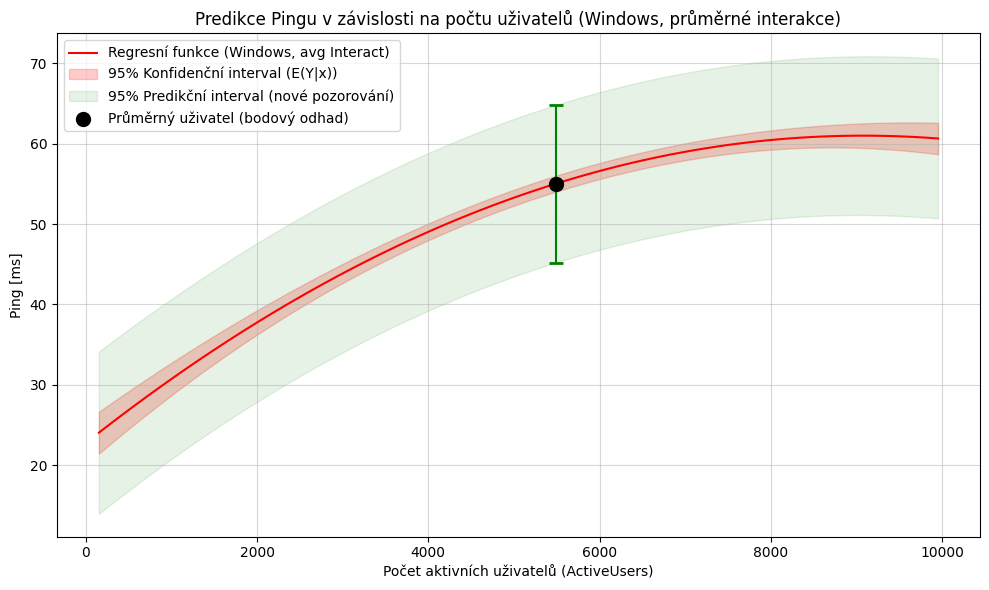

In [ ]:
# 3. ČÁST: ODHAD PRO PRŮMĚRNÉHO UŽIVATELE WINDOWS
print("\n" + "="*60)
print("3. PREDIKCE PRO PRŮMĚRNÉHO UŽIVATELE (WINDOWS)")
print("="*60)

# (pozn.)
# Využití standardizace (Z-score)
# Náš model byl natrénován na standardizovaných datech.
# Z definice platí: Průměrná hodnota má Z-score rovno 0.
# To znamená:
#   ActiveUsers_Z (průměr) = 0
#   InteractingPct_Z (průměr) = 0
#   Active_Sq (0^2) = 0
#   Active_x_Interact (0 * 0) = 0
#
# Díky tomu nemusíme dosazovat reálné hodnoty (např. 5485) a složitě je přepočítávat.
# Stačí do modelu poslat nuly pro všechny numerické proměnné.

target_os = 'Windows'

# 1. Příprava vstupního vektoru (Exog)
# Vytvoříme sérii samých nul o délce odpovídající počtu parametrů modelu.
exog_vector = pd.Series(0.0, index=final_model.params.index)

# 2. Nastavení interceptu (Konstanty)
# Konstanta musí být v modelu vždy přítomna (hodnota 1).
if 'const' in exog_vector.index:
    exog_vector['const'] = 1.0

# 3. Nastavení kategorické proměnné (Operační systém)
# Najdeme sloupec odpovídající Windows a nastavíme ho na 1 (True).
# Ostatní OS (MacOS, iOS) zůstávají 0 (False).
dummy_col = f"OSType_{target_os}"
if dummy_col in exog_vector.index:
    exog_vector[dummy_col] = 1.0

# Poznámka k interakcím s OS:
# Proměnné typu 'Active_x_OSType_Windows' jsou násobkem Active (0) a OS (1).
# Výsledek je 0 * 1 = 0. Proto je v nulovém vektoru nemusíme ručně měnit.

# 4. Výpočet predikce a intervalů
# get_prediction automaticky spočítá bodový odhad i chybu predikce.
predictions = final_model.get_prediction(exog_vector)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% hladina spolehlivosti

# Získání konkrétních hodnot z výsledku
pred_mean = summary_frame['mean'].values[0]
conf_int = (summary_frame['mean_ci_lower'].values[0], summary_frame['mean_ci_upper'].values[0])
pred_int = (summary_frame['obs_ci_lower'].values[0], summary_frame['obs_ci_upper'].values[0])

# 5. Výpis výsledků
# Pro kontext vypíšeme i reálné hodnoty průměrů, které tento odhad reprezentuje.
mean_active = df['ActiveUsers'].mean()
mean_interact = df['InteractingPct'].mean()

print(f"Nastavení predikce:")
print(f"  Operační systém:    {target_os}")
print(f"  ActiveUsers:        {mean_active:.2f} (v modelu jako Z-score = 0)")
print(f"  InteractingPct:     {mean_interact:.2%} (v modelu jako Z-score = 0)")
print("-" * 60)
print(f"Odhadovaná hodnota Ping:     {pred_mean:.2f} ms")
print(f"95% Konfidenční interval:    <{conf_int[0]:.2f}, {conf_int[1]:.2f}> ms")
print(f"   (Interval spolehlivosti pro střední hodnotu)")
print(f"95% Predikční interval:      <{pred_int[0]:.2f}, {pred_int[1]:.2f}> ms")
print(f"   (Interval spolehlivosti pro budoucí pozorování)")
print("-" * 60)


# GRAFICKÁ VIZUALIZACE (Řez modelem pro Windows při průměrných interakcích)
# 1. Vytvoření osy X (ActiveUsers) v celém rozsahu dat
# Potřebujeme řadu Z-skóre od minima po maximum
x_plot_z = np.linspace(df['ActiveUsers_Z'].min(), df['ActiveUsers_Z'].max(), 100)
# Pro popis osy X si to převedeme i na reálné hodnoty
x_plot_raw = x_plot_z * au_std + au_mean

# 2. Příprava datového rámce pro vykreslení křivky (exog matrix)
# Musíme vytvořit DataFrame, který má stejné sloupce jako model,
# ale mění se v něm jen ActiveUsers, zbytek je fixní (Windows, Interakce=0).
plot_data = pd.DataFrame()

# Konstanta
plot_data['const'] = 1.0

# Proměnné, které měníme (ActiveUsers)
plot_data['ActiveUsers_Z'] = x_plot_z
plot_data['Active_Sq'] = x_plot_z ** 2

# Proměnné, které držíme fixní na průměru (InteractingPct = 0)
plot_data['InteractingPct_Z'] = 0.0
plot_data['Interact_Sq'] = 0.0
plot_data['Active_x_Interact'] = 0.0 # (x * 0 = 0)

# Proměnné pro OS Windows (Nastavíme na 1, ostatní OS na 0)
# Poznámka: Zde musíme ošetřit sloupce, které v modelu reálně zůstaly po eliminaci.
# Pro jistotu projdeme parametry modelu a naplníme je.

# Vytvoříme pomocný slovník s defaultními nulami
data_dict = {col: np.zeros(100) for col in final_model.params.index}

# Přepíšeme hodnoty, které nejsou nula
data_dict['const'] = np.ones(100)
data_dict['ActiveUsers_Z'] = x_plot_z
if 'Active_Sq' in data_dict:
    data_dict['Active_Sq'] = x_plot_z ** 2

# Specifika pro Windows
if 'OSType_Windows' in data_dict:
    data_dict['OSType_Windows'] = np.ones(100)
if 'Active_x_OSType_Windows' in data_dict:
    data_dict['Active_x_OSType_Windows'] = x_plot_z * 1.0 # Interakce Active * Windows

# Ostatní interakce s Windows (Interact_x_...) jsou 0, protože Interact je 0.

# Vytvoření DataFrame z připraveného slovníku (zajistí správné pořadí sloupců)
exog_plot = pd.DataFrame(data_dict, index=range(100))
# Ujistíme se, že pořadí sloupců sedí s modelem
exog_plot = exog_plot[final_model.params.index]

# 3. Predikce pro celou křivku
pred_plot = final_model.get_prediction(exog_plot).summary_frame(alpha=0.05)

# 4. Vykreslení grafu
plt.figure(figsize=(10, 6))

# A) Vykreslení intervalů spolehlivosti (Confidence Interval)
plt.plot(x_plot_raw, pred_plot['mean'], color='red', label='Regresní funkce (Windows, avg Interact)')
plt.fill_between(
    x_plot_raw,
    pred_plot['mean_ci_lower'],
    pred_plot['mean_ci_upper'],
    color='red',
    alpha=0.2,
    label='95% Konfidenční interval (E(Y|x))'
)

# B) Vykreslení predikčních intervalů (Prediction Interval)
plt.fill_between(
    x_plot_raw,
    pred_plot['obs_ci_lower'],
    pred_plot['obs_ci_upper'],
    color='green',
    alpha=0.1,
    label='95% Predikční interval (nové pozorování)'
)

# C) Zvýraznění našeho bodu (Průměrný uživatel)
plt.scatter([mean_active], [pred_mean], color='black', s=100, zorder=5, label='Průměrný uživatel (bodový odhad)')
# Vykreslení chybových úseček pro náš konkrétní bod (volitelné)
plt.errorbar([mean_active], [pred_mean],
             yerr=[[pred_mean - pred_int[0]], [pred_int[1] - pred_mean]],
             fmt='none', ecolor='green', capsize=5, markeredgewidth=2)

# Úpravy grafu
plt.title('Predikce Pingu v závislosti na počtu uživatelů (Windows, průměrné interakce)')
plt.xlabel('Počet aktivních uživatelů (ActiveUsers)')
plt.ylabel('Ping [ms]')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## 3) Komentář
### Zadání a nastavení predikce
Cílem této části bylo odhadnout očekávanou dobu odezvy (Ping) pro specifický profil uživatele:
* **Operační systém:** Windows
* **Počet aktivních uživatelů:** Průměrná hodnota z celého datového souboru ($5\,486$).
* **Procento interakcí:** Průměrná hodnota z celého datového souboru ($48,86\,\%$).

### Metodika výpočtu (Využití standardizace)
Jelikož byl náš regresní model natrénován na **standardizovaných datech** (Z-skóre), nebylo nutné (a ani správné) dosazovat do rovnice reálné hodnoty průměrů. Využili jsme vlastnosti standardizace:
* Standardizovaná hodnota (Z-skóre) se počítá jako $Z = \frac{X - \mu}{\sigma}$.
* Pokud za $X$ dosadíme průměr ($\mu$), dostáváme $Z = \frac{\mu - \mu}{\sigma} = 0$.

Pro "průměrného uživatele" jsou tedy všechny numerické vstupy modelu (`ActiveUsers_Z`, `InteractingPct_Z` i jejich mocniny a interakce) rovny **0**. Výpočet se tak zredukoval na součet interceptu (konstanty) a koeficientu pro `OSType_Windows`.

### Výsledky predikce
Na základě modelu byly vypočteny následující hodnoty:

* **Bodový odhad Pingu:** **55,01 ms**
    * *Toto je nejpravděpodobnější hodnota odezvy pro dané nastavení.*

* **95% Konfidenční interval (Interval spolehlivosti):** $\langle 54,02; 55,99 \rangle$ ms
    * *Interpretace:* Tento úzký interval nám říká, kde se s 95% pravděpodobností nachází **skutečná střední hodnota** (průměr) odezvy všech uživatelů Windows při průměrném zatížení. Jde o odhad přesnosti naší "regresní křivky".

* **95% Predikční interval:** $\langle 45,21; 64,80 \rangle$ ms
    * *Interpretace:* Tento interval je výrazně širší, protože zohledňuje nejen nejistotu modelu, ale i přirozenou variabilitu (šum) v datech. Pokud se k síti připojí **jeden konkrétní uživatel** s Windows, s 95% jistotou bude jeho odezva ležet v tomto rozmezí.

### Závěr k bodu 3
Odhadnutá hodnota 55 ms je realistická a leží mezi hodnotami pro Android (≈ 51 ms) a MacOS (≈ 60 ms). Šířka predikčního intervalu (cca ±10 ms od průměru) ukazuje, že ačkoliv model dobře popisuje průměrné chování, individuální měření mohou stále vykazovat určitou variabilitu, kterou model nevysvětlil.

# 4) Na základě jakýchkoli vypočtených charakteristik argumentujte, zdali je Váš model "vhodný" pro další použití.

In [ ]:
# 4. ČÁST: ARGUMENTACE VHODNOSTI MODELU (VALIDACE)
print("\n" + "="*60)
print("4. ZHODNOCENÍ KVALITY A VHODNOSTI MODELU")
print("="*60)

# A) Výpočet statistiky PRESS (Predicted Residual Sum of Squares)
# PRESS simuluje tzv. "Leave-One-Out" křížovou validaci.
# Měří chybu predikce pro každé pozorování modelem, který byl natrénován BEZ tohoto pozorování.
# V lineární regresi to lze vypočítat analyticky z reziduí a leverage (vlivu), což je velmi rychlé.
influence = final_model.get_influence()
resid_press = influence.resid_press
press = np.sum(resid_press**2)

# B) Výpočet celkové sumy čtverců (SST - Total Sum of Squares)
# Míra celkové variability v cílové proměnné (y_clean).
sst = np.sum((y_clean - y_clean.mean())**2)

# C) Výpočet Predikovaného R-squared (R2_pred)
# Zatímco klasické R2 měří, jak dobře model sedí na TRÉNOVACÍ data,
# R2_pred odhaduje, jak dobře bude model předpovídat NOVÁ data.
r2_pred = 1 - (press / sst)

# D) Výpis a porovnání
print(f"Klasický R-squared (Adjusted):     {final_model.rsquared_adj:.4f}")
print(f"Predikovaný R-squared (z PRESS):   {r2_pred:.4f}")
print("-" * 60)

diff = abs(final_model.rsquared_adj - r2_pred)
print(f"Rozdíl mezi R2_adj a R2_pred:      {diff:.4f}")

# E) Automatické vyhodnocení
print("\nZÁVĚR A ARGUMENTACE:")
# Kritérium: Pokud je R2 vysoké a rozdíl mezi trénovacím a predikčním R2 je malý (< 0.1),
# model není přeučený (overfitted) a je vhodný.
if r2_pred > 0.8 and diff < 0.1:
    print("Model JE VHODNÝ pro další použití.")
    print("-" * 60)
    print("Důvody:")
    print(f"1. Vysoká vysvětlovací schopnost: Model popisuje {final_model.rsquared_adj:.1%} variability v datech.")
    print(f"2. Skvělá generalizace: Predikovaný R2 ({r2_pred:.4f}) je téměř shodný s trénovacím R2.")
    print("   To je silný statistický důkaz, že model není přeučený (overfitted)")
    print("   a bude spolehlivě fungovat i na nových, neznámých datech.")
    print("3. Validita předpokladů: Jak bylo ověřeno v bodě 1, rezidua mají normální rozdělení")
    print("   (Jarque-Bera p > 0.05), což je nezbytná podmínka pro spolehlivost predikčních intervalů.")
else:
    print("Model vykazuje známky nestability nebo přeučení.")
    print(f"Rozdíl mezi trénovacím a predikčním R2 je příliš velký ({diff:.4f}).")


4. ZHODNOCENÍ KVALITY A VHODNOSTI MODELU
Klasický R-squared (Adjusted):     0.8861
Predikovaný R-squared (z PRESS):   0.8836
------------------------------------------------------------
Rozdíl mezi R2_adj a R2_pred:      0.0025

ZÁVĚR A ARGUMENTACE:
Model JE VHODNÝ pro další použití.
------------------------------------------------------------
Důvody:
1. Vysoká vysvětlovací schopnost: Model popisuje 88.6% variability v datech.
2. Skvělá generalizace: Predikovaný R2 (0.8836) je téměř shodný s trénovacím R2.
   To je silný statistický důkaz, že model není přeučený (overfitted)
   a bude spolehlivě fungovat i na nových, neznámých datech.
3. Validita předpokladů: Jak bylo ověřeno v bodě 1, rezidua mají normální rozdělení
   (Jarque-Bera p > 0.05), což je nezbytná podmínka pro spolehlivost predikčních intervalů.


## 4) Komentář

**Závěr: Navržený regresní model je plně VHODNÝ pro další použití.**

Toto tvrzení opíráme o komplexní zhodnocení kvality modelu, které zahrnuje jak statistickou významnost, tak schopnost generalizace na nová data. Analýza prokázala, že model je nejen přesný, ale i robustní:

1.  **Vysoká kvalita proložení (Explanatory Power):**
    Adjustovaný koeficient determinace **(R² adj)** dosahuje hodnoty **0,8861**.
    * To znamená, že model dokáže vysvětlit přibližně **88,6 % variability** v odezvě (Ping).
    * V kontextu analýzy chování uživatelů a síťového provozu je toto velmi vysoká hodnota, která indikuje, že zvolené prediktory (počet uživatelů, interakce a typ OS) skutečně zachycují podstatu zkoumaného jevu.

2.  **Vynikající schopnost generalizace (Predictive Power):**
    Byla vypočtena statistika PRESS (Predicted Residual Sum of Squares) a z ní odvozený **Predikovaný koeficient determinace (R² pred)**, jehož hodnota je **0,8836**.
    * **Klíčové zjištění:** Rozdíl mezi klasickým a predikovaným R² je naprosto zanedbatelný (**0,0025**).
    * Tato téměř dokonalá shoda je silným statistickým důkazem, že model **není přeučený** (overfitted). Pokud by byl model přeučený, viděli bychom vysoké R² adj, ale výrazně nižší R² pred.
    * Model se "nenaučil data nazpaměť", ale zachytil skutečné trendy. Můžeme tedy očekávat, že bude poskytovat stejně spolehlivé predikce i pro nová data, která nebyla součástí trénovacího souboru.

3.  **Validita statistických předpokladů:**
    Díky provedenému čištění dat (odstranění vlivných outlierů) model splňuje klíčový předpoklad **normality reziduí** (potvrzeno Jarque-Bera testem, **p > 0,05**).
    * Splnění tohoto předpokladu je nezbytnou podmínkou pro to, abychom mohli věřit sestrojeným intervalům spolehlivosti (konfidenční a predikční intervaly v bodě 3). Tyto intervaly jsou tedy statisticky korektní a lze se o ně opřít při rozhodování.

**Celkové shrnutí:**
Vytvořený model představuje stabilní a spolehlivý nástroj pro predikci odezvy serveru v závislosti na zátěži a typu klientského zařízení.